# Dataset

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Чтение из файла

In [67]:
df = pd.read_csv('../dataset/texts_from_avito.csv', sep=';')
df = df[df['тема'].notna()]
df = df[['тема', 'текст']]
# df = df[df['тема'] != "не вопрос клиента"]
df

,тема,текст
0,шуруповерт,"добрый вечер! подскажите, у вас можно взять в ..."
1,пылесос,Здравствуйте) сколько стоит аренда строительно...
2,плиткорез ручной,Доброе утро. Подскажите пожалуйста в какую цен...
3,фен,Доброе утро Есть строительный фен на аккумулят...
4,не вопрос клиента,Добрый день
...,...,...
911,дрель для алмазного бурения,"Добрый утро, есть дрель для сухого алмазного ..."
912,штроборез,"Здравствуйте, хотел бы взять у вас в прокат ш..."
913,не вопрос клиента,Здравствуйте
914,домкрат бутылочный,Здравствуйте! Какие домкраты есть в аренду с ...


Тексты запросов содержат много "паразитных" слов, не имеющих прямого отношения к теме запроса.
Стоит удалить их на этапе предобработки.

## Предобработка

In [68]:
def clear_text(text: str) -> str:
    # функция очистки текстов от паразитных слов, не относящихся к теме запроса
    
    trash_values = [
        'добрый вечер', 
        'добрый день', 
        'доброе утро',
        'добрый утро',
        'здравствуйте',
        'подскажите',
        'пожалуйста',
        'хотелось',
        'интересует',
        'нужен',
        'нужно',
        'хочу',
        'надо',
        'можно',
        'аренда',
        'аренду',
        'хочу',
        'хотел бы',
        'в наличии',
        'сколько стоит',
    ]
    text = text.lower()
    for value in trash_values:
        text = text.replace(value, '')
    return text

In [69]:
# очистка текстов от паразитных слов

df['текст'] = df['текст'].map(clear_text)
df = df[df['текст'] != '']
df

,тема,текст
0,шуруповерт,"! , у вас взять в шурповерт?"
1,пылесос,) строительного пылесоса на сутки?
2,плиткорез ручной,. в какую цену у вас следующие инструменты: ...
3,фен,есть строительный фен на аккумуляторной батареи?
5,паркетно-шлифовальная машина,! обновить деревянный пол на даче. у вас есть...
...,...,...
910,генератор,"! бензогенератор в - 6,5-7 квт. 1-фазный. на..."
911,дрель для алмазного бурения,", есть дрель для сухого алмазного бурения?"
912,штроборез,", взять у вас в прокат штроборез, он у вас с..."
914,домкрат бутылочный,! какие домкраты есть в с вечера четверга по...


## Анализ

In [71]:
theme_counts = df['тема'].value_counts()
print(f"Всего тем: {len(theme_counts)}")
print(f"Всего обращений: {len(df)}")
print(f"Среднее: {theme_counts.mean():.1f} обращений на тему")
print(f"Медиана: {theme_counts.median():.1f}")
print(f"Мин: {theme_counts.min()}")
print(f"Макс: {theme_counts.max()}")
print(f"Стандартное отклонение: {theme_counts.std():.1f}")

print("\nПроцентили:")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"{p}% тем имеют ≤ {np.percentile(theme_counts, p):.0f} обращений")

Всего тем: 90
Всего обращений: 838
Среднее: 9.3 обращений на тему
Медиана: 4.0
Мин: 1
Макс: 79
Стандартное отклонение: 13.8

Процентили:
10% тем имеют ≤ 1 обращений
25% тем имеют ≤ 1 обращений
50% тем имеют ≤ 4 обращений
75% тем имеют ≤ 10 обращений
90% тем имеют ≤ 27 обращений
95% тем имеют ≤ 36 обращений
99% тем имеют ≤ 67 обращений


In [56]:
# Частые и редкие темы

print("САМЫЕ ЧАСТЫЕ ТЕМЫ:")
for theme, count in theme_counts.head(10).items():
    print(f"  {count:3d} | {theme}")

print("\n" + "="*50)

print("РЕДКИЕ ТЕМЫ (≤3 примеров):")
rare_themes = theme_counts[theme_counts <= 3]
if len(rare_themes) > 0:
    for theme, count in rare_themes.items():
        print(f"  {count} | {theme}")

САМЫЕ ЧАСТЫЕ ТЕМЫ:
   79 | перфоратор
   65 | пылесос
   48 | не вопрос клиента
   45 | торцовочная пила
   36 | нет такого инструмента
   35 | шуруповерт
   30 | лобзик
   29 | лестница
   28 | паркетно-шлифовальная машина
   27 | УШМ

РЕДКИЕ ТЕМЫ (≤3 примеров):
  3 | бензобур
  3 | станок распиловочный
  3 | пушка дизельная
  3 | пушка тепловая
  2 | культиватор
  2 | подъемник ГКЛ
  2 | мотопомпа
  2 | перфоратор аккумуляторный
  2 | воздуходувка
  2 | детектор проводки
  2 | удлинитель электричексий
  2 | лестница-трансформер
  2 | пушка электрическая
  2 | нейлер пневматический
  1 | пила дисковая аккумуляторная
  1 | вибратор
  1 | коронка по бетону
  1 | пистолет для герметика
  1 | домкрат подкатной
  1 | шнек для бензобура
  1 | металлоискатель
  1 | рохля
  1 | установка алмазного бурения
  1 | триммер аккумуляторный
  1 | вышка тура
  1 | моющий пылесос
  1 | тачка
  1 | дрель магнитная
  1 | осушитель воздуха
  1 | бензопила
  1 | прогрев бетона
  1 | пила ленточная
  1 | п

🔴 Редкие (1-3 примера): 40 тем (44.4%)
🟡 Низкие (4-10): 28 тем (31.1%)
🟢 Средние (11-30): 16 тем (17.8%)
🔵 Частые (31+): 6 тем (6.7%)


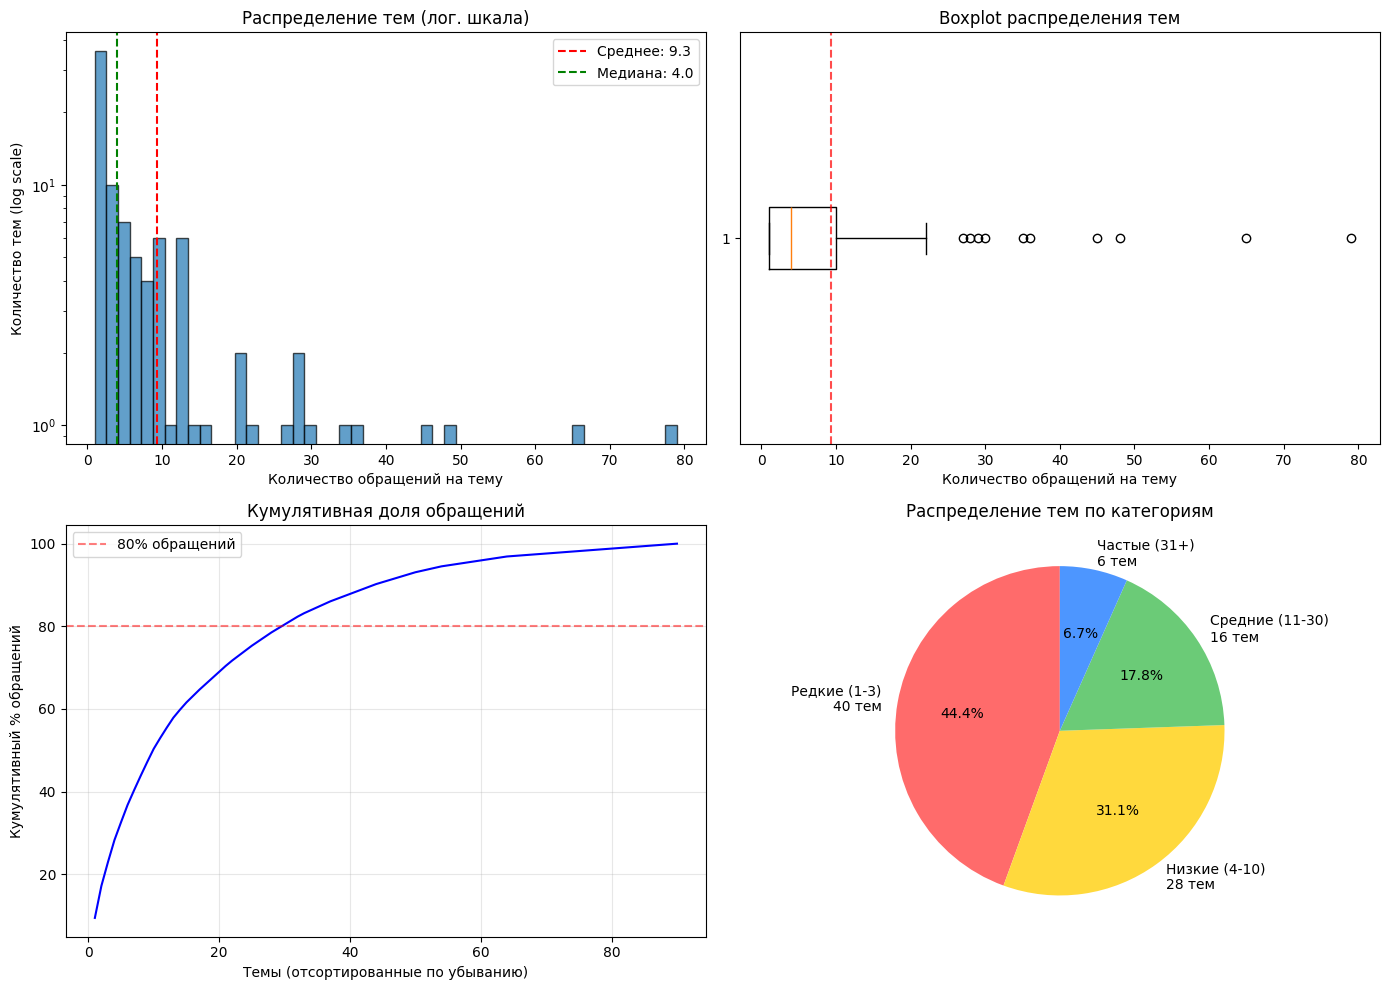

In [57]:
# наглядные графики, подслушанные у deepseek

def categorize_themes(theme_counts):
    rare = theme_counts[theme_counts <= 3].count()      # 1-3 примера
    low = theme_counts[(theme_counts >= 4) & (theme_counts <= 10)].count()
    medium = theme_counts[(theme_counts >= 11) & (theme_counts <= 30)].count()
    high = theme_counts[theme_counts >= 31].count()
    
    print(f"🔴 Редкие (1-3 примера): {rare} тем ({rare/len(theme_counts)*100:.1f}%)")
    print(f"🟡 Низкие (4-10): {low} тем ({low/len(theme_counts)*100:.1f}%)")
    print(f"🟢 Средние (11-30): {medium} тем ({medium/len(theme_counts)*100:.1f}%)")
    print(f"🔵 Частые (31+): {high} тем ({high/len(theme_counts)*100:.1f}%)")
    
    return {'rare': rare, 'low': low, 'medium': medium, 'high': high}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Гистограмма с логарифмической шкалой
axes[0,0].hist(theme_counts, bins=50, edgecolor='black', alpha=0.7)
axes[0,0].set_yscale('log')
axes[0,0].set_xlabel('Количество обращений на тему')
axes[0,0].set_ylabel('Количество тем (log scale)')
axes[0,0].set_title('Распределение тем (лог. шкала)')
axes[0,0].axvline(theme_counts.mean(), color='red', linestyle='--', label=f'Среднее: {theme_counts.mean():.1f}')
axes[0,0].axvline(theme_counts.median(), color='green', linestyle='--', label=f'Медиана: {theme_counts.median():.1f}')
axes[0,0].legend()

# 2. Boxplot
axes[0,1].boxplot(theme_counts, vert=False)
axes[0,1].set_xlabel('Количество обращений на тему')
axes[0,1].set_title('Boxplot распределения тем')
axes[0,1].axvline(theme_counts.mean(), color='red', linestyle='--', alpha=0.7)

# 3. Кумулятивная доля
sorted_counts = theme_counts.sort_values(ascending=False)
cumulative = sorted_counts.cumsum() / sorted_counts.sum() * 100
axes[1,0].plot(range(1, len(cumulative)+1), cumulative, 'b-')
axes[1,0].set_xlabel('Темы (отсортированные по убыванию)')
axes[1,0].set_ylabel('Кумулятивный % обращений')
axes[1,0].set_title('Кумулятивная доля обращений')
axes[1,0].axhline(80, color='r', linestyle='--', alpha=0.5, label='80% обращений')
axes[1,0].grid(True, alpha=0.3)
axes[1,0].legend()

# 4. Распределение по категориям
cat_counts = categorize_themes(theme_counts)
labels = [f'Редкие (1-3)\n{cat_counts["rare"]} тем', 
          f'Низкие (4-10)\n{cat_counts["low"]} тем',
          f'Средние (11-30)\n{cat_counts["medium"]} тем',
          f'Частые (31+)\n{cat_counts["high"]} тем']
sizes = [cat_counts['rare'], cat_counts['low'], cat_counts['medium'], cat_counts['high']]
colors = ['#ff6b6b', '#ffd93d', '#6bcb77', '#4d96ff']
axes[1,1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Распределение тем по категориям')

plt.tight_layout()
plt.show()

## Итог

Данные имеют сильный дисбаланс: 75% тем имеют ≤ 10 обращений.
Данных достаточно мало (всего 838 примеров для 90 тем).
Скорее всего, придётся добирать датасет.

# Baseline

Будем хранить эмебеддинги для всех известных примеров и для классификации нового искать ближайщий.

In [6]:
import os
from sklearn.neighbors import NearestNeighbors
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split

## Деление на train и test

In [74]:
train, test = train_test_split(df, test_size=0.1, random_state=42)
print(f"Train: {len(train)}, Test: {len(test)}")

Train: 754, Test: 84


## Создание эмбеддингов

In [ ]:
try:
    with open(os.path.join('..', 'config', 'HF_TOKEN.txt'), encoding='utf-8') as f:
        token = f.read()
        os.environ['HF_TOKEN'] = token
except FileNotFoundError:
    pass
model = SentenceTransformer('intfloat/multilingual-e5-small')
embeddings = model.encode(train['текст'].tolist())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Обучение kNN

In [76]:
knn = NearestNeighbors(n_neighbors=1, metric='cosine')
knn.fit(embeddings)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


## Тестирование

In [77]:
test_texts = test['текст'].tolist()
test_labels = test['тема'].tolist()

acc = 0
for test_text, test_label in zip(test_texts, test_labels):

    new_text_embedding = model.encode([test_text])
    distances, indices = knn.kneighbors(new_text_embedding)
    predicted_theme = train.iloc[indices[0][0]]['тема']
    if predicted_theme==test_label:
        sym = '🟢'
    else:
        sym = '🔴'
    print(test_text, '\n', sym, ' Предсказано: ', predicted_theme, ', На самом деле: ', test_label)
    acc += predicted_theme==test_label

print(f'\nТочность: {acc/len(test_texts)}')

 ,  есть невелиры ? 
 🔴  Предсказано:  штроборез , На самом деле:  нивелир оптический
!  торцовочник чтобы выполнить запил плинтуса под разные углы высотой 80 мм. сколько будет стоить  такого инструмента и условия аренды. 
 🟢  Предсказано:  торцовочная пила , На самом деле:  торцовочная пила
 ,   торцовочной пилы с диском для алюминия 
 🟢  Предсказано:  торцовочная пила , На самом деле:  торцовочная пила
, нужна дрель или шуруповерт(что дешевле)  и сверло на 6  на пару часов 
 🟢  Предсказано:  дрель-шуруповерт , На самом деле:  дрель-шуруповерт
  генератор или преобразователь для потребителя  1500вт 
 🟢  Предсказано:  генератор , На самом деле:  генератор
,  перфоратора  ? 
 🟢  Предсказано:  перфоратор , На самом деле:  перфоратор
, сколько будет стоить  строительного пылесоса с мешком для мусора? 
 🟢  Предсказано:  пылесос , На самом деле:  пылесос
. необходимо арендовать реноватор.  по наличию. еще , идет ли в комплекте оснастка? 
 🟢  Предсказано:  реноватор , На самом деле:  реноват

Baseline дает точность 0.67

## Итог

Реализован baseline, дающий точность 0.67

# Планы

Расширить датасет
- донабором данных
- аугментацией имеющихся данных
- автоматизировать получение новых примеров через LLM

Попробовать дообучить предобученные модели 
- cointegrated/rubert-tiny2 
- DeepPavlov/rubert-base-cased

## Метрики

Для оценки качества моделей планируется использовать F1-score.
Так что же почитал, что полезно будет смотреть на Per-class F1 (для поиска проблемных тем) и Confusion Matrix (есть ли ошибки на похожих темах).